# Simulation — Fixed N

## Setup

In [ ]:
#| label: setup
#| include: false

# For CFA population models
source(here::here("Scripts", "DataAppendixScripts", "models.R"))

# For DRY (Don't repeat yourself) parameters
source(here::here("Scripts", "DataAppendixScripts", "helpers.R"))

# For simulations caching
source(here::here("Scripts", "DataAppendixScripts", "cache_utils.R"))

# For loading existing simulations cache
source(here::here("Scripts", "DataAppendixScripts", "cache_loader.R"))

# Load existing simulations cache if available (cache_loader.R)
cache_load_existing()

## Power analysis with fixed N

The preceding sections searched for the minimum $N$ required to achieve adequate power under isolated conditions, with requirements generally converging below $N = 231$. This section shifts perspective to a design-feasibility framework: fixing a candidate recruitment target at $N = 250$ (defined as `N_TARGET` in `helpers.R`) and stress-testing whether this planned sample size reliably sustains statistical power when subjected to compound real-world conditions simultaneously — 10% MCAR missingness and mild non-normality \[@feng2023; @simsem2021\].

This design choice mirrors applied research scenarios where sample sizes are bounded by recruitment capacity or budgetary constraints. Running 1,000 replications at a fixed $N = 250$ provides high-precision sampling stability, free from the interpolation jitter inherent in sparse varying-$N$ grids \[@wang2021; @jobst2023\].

In [ ]:
#| label: sim-fixed-popmodel

popmodel_fixed <- cache_or_run("popmodel_fixed", {
    sim(
        REP,                    # Number of replications (defined in helpers.R)
        n = N_TARGET,           # Fixed sample size (defined in helpers.R)
        pmMCAR = P_MCAR,        # Percentage of missing Completely At Random (MCAR) data (defined in helpers.R)
        analyzemodel,           # Model to analyze (defined in models.R)
        generate = popmodel,    # Population model to simulate from (defined in models.R)
        indDist = dist,         # Individual distribution of response variables (defined in helpers.R)
        std.lv = TRUE,          # Standardize latent variables to unit variance
        lavaanfun = "cfa",      # Use confirmatory factor analysis (CFA)
        estimator = "mlr",      # Use robust maximum likelihood (MLR) estimator
        missing = "fiml",       # Use Full Information Maximum Likelihood (FIML) for missing data
        seed = SEED,            # Random seed for reproducibility (defined in helpers.R)
        multicore = TRUE        # Use multiple cores for parallel processing
    )
})

In [ ]:
#| label: sim-fixed-h1model

h1model_fixed <- cache_or_run("h1model_fixed", {
    sim(
        REP,                    # Number of replications (defined in helpers.R)
        n = N_TARGET,           # Fixed sample size (defined in helpers.R)
        pmMCAR = P_MCAR,        # Percentage of missing Completely At Random (MCAR) data (defined in helpers.R)
        analyzemodel,           # Model to analyze (defined in models.R)
        generate = h1model,     # Population model with cross loadings (defined in models.R)
        indDist = dist,         # Individual distribution of response variables (defined in helpers.R)
        std.lv = TRUE,          # Standardize latent variables to unit variance
        lavaanfun = "cfa",      # Use confirmatory factor analysis (CFA)
        estimator = "mlr",      # Use robust maximum likelihood (MLR) estimator
        missing = "fiml",       # Use Full Information Maximum Likelihood (FIML) for missing data
        seed = SEED,            # Random seed for reproducibility (defined in helpers.R)
        multicore = TRUE        # Use multiple cores for parallel processing
    )
})

### Power curves for fit indices

With $N$ fixed, `plotPowerFit()` no longer traces power as a function of sample size. Instead, the figure displays the empirical distributions of each fit index under the reference and misspecified conditions across replications, alongside the cutoff derived from the reference model at the chosen $\alpha$ level. The visual separation between the two distributions is the graphical counterpart of the power values reported in the table below \[@simsem2021; @mcneish2021\].

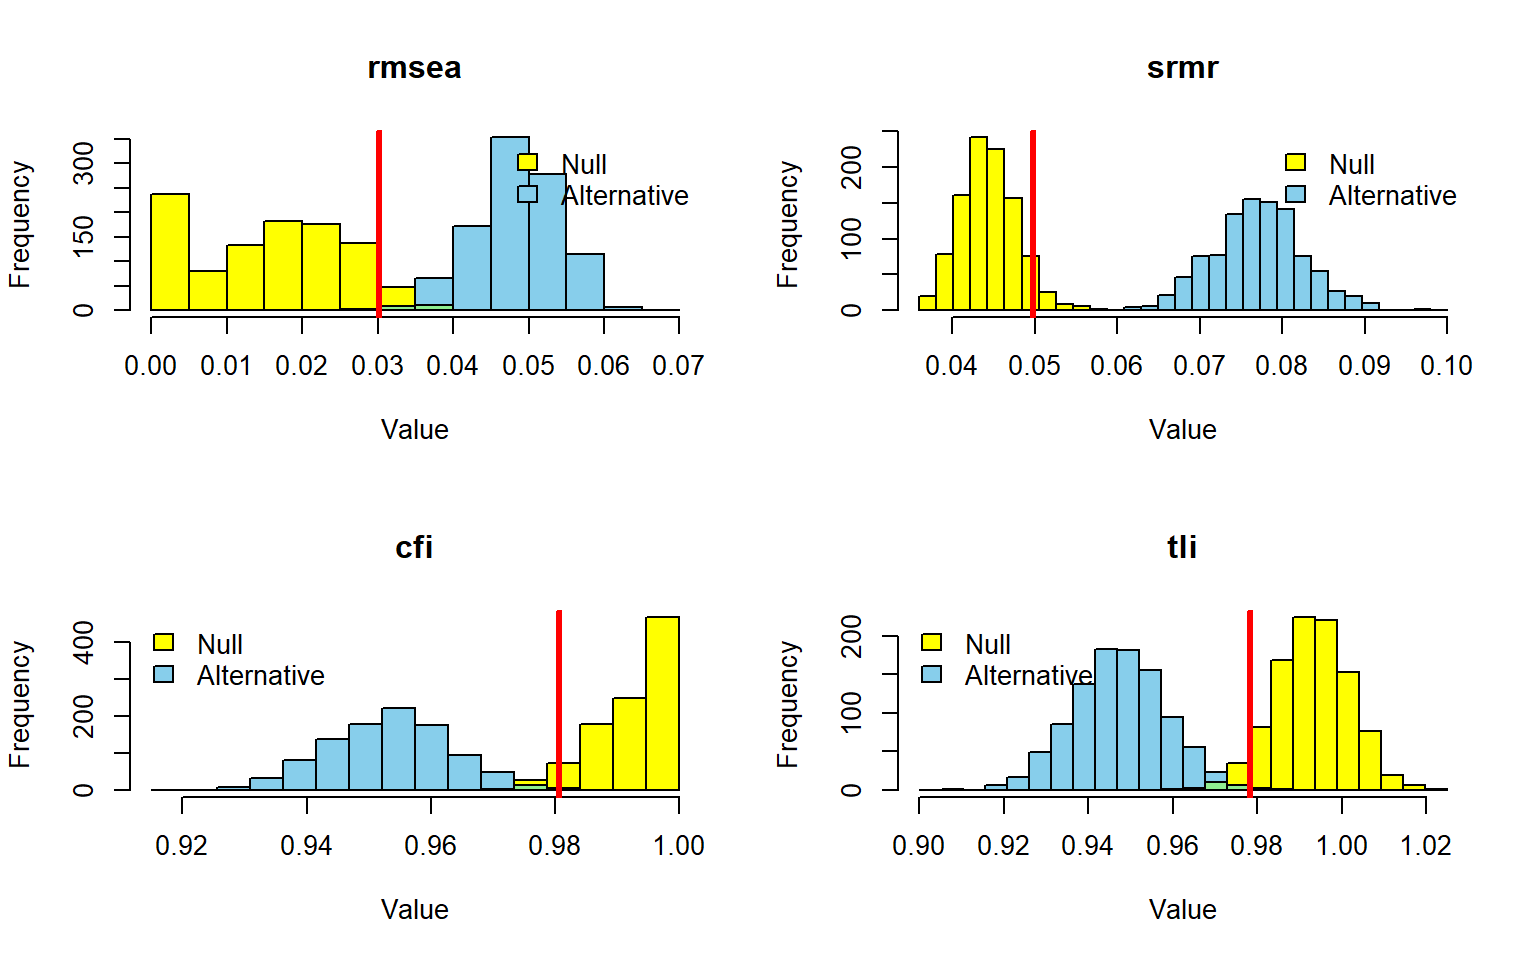

In [ ]:
#| label: fig-power-curve-fixed
#| fig-cap: "Power curves for fit indices with fixed sample size."
#| fig-width: 8
#| fig-height: 5

plotPowerFit(
    h1model_fixed,    # Data simulated under H1 (with cross-loadings)
    popmodel_fixed,   # Data simulated under H0 (null model)
    alpha = ALPHA,    # Significance level for determining power (see helpers.R)
    usedFit = FITS    # RMSEA, SRMR, CFI, and TLI fit indices to display (see helpers.R)
)

### Power and cutoff values for fit indices

In [ ]:
#| label: tbl-power-cutoff-fixed
#| tbl-cap: "Power and fit index cutoff values with fixed sample size."

# Estimate power for rejecting the misspecified model (h1model_fixed)
# using fit-index cutoffs implied by the null model.
power_fixed <- getPowerFit(
  h1model_fixed,                 # Data simulated under H1 (with cross-loadings)
  nullObject = popmodel_fixed,   # Data simulated under H0 (null model)
  alpha = ALPHA,                 # Significance level (see helpers.R)
  usedFit = FITS                 # RMSEA, SRMR, CFI, and TLI fit indices to display (see helpers.R)
)

# Derive empirical cutoff values for the selected fit indices
# from the null-model sampling distribution under the same conditions.
cutoff_fixed <- getCutoff(
  popmodel_fixed,     # Data simulated under H0 (null model)
  alpha = ALPHA,      # Significance level (see helpers.R)
  usedFit = FITS      # RMSEA, SRMR, CFI, and TLI fit indices to display (see helpers.R)
)

# Subset power to the four requested fit indices
power_fixed_clean <- power_fixed[FITS]
cutoff_fixed_clean <- cutoff_fixed[1, FITS]

# Combine power and cutoff values into a compact summary table.
power_cutoff_fixed <- rbind(
  "Power"  = as.numeric(power_fixed_clean),
  "Cutoff" = as.numeric(cutoff_fixed_clean)
)

# Standardize column names for presentation.
colnames(power_cutoff_fixed) <- toupper(FITS)

# Print the table.
knitr::kable(power_cutoff_fixed, digits = 3, align = "c")

            RMSEA   SRMR    CFI     TLI
  -------- ------- ------ ------- -------
  Power     0.998   1.00   0.997   0.997
  Cutoff    0.030   0.05   0.981   0.978


## Power analysis with traditional cutoffs

The same fixed-$N$ simulation is now re-evaluated using conventional rule-of-thumb thresholds in place of the empirically derived cutoffs used above. This is a deliberate contrast: by holding $N$, the data-generating model, and the analysis model constant while changing only the decision criterion, the comparison isolates the contribution of the cutoff choice to the power conclusion \[@mcneish2021; @kyriazos2018\].

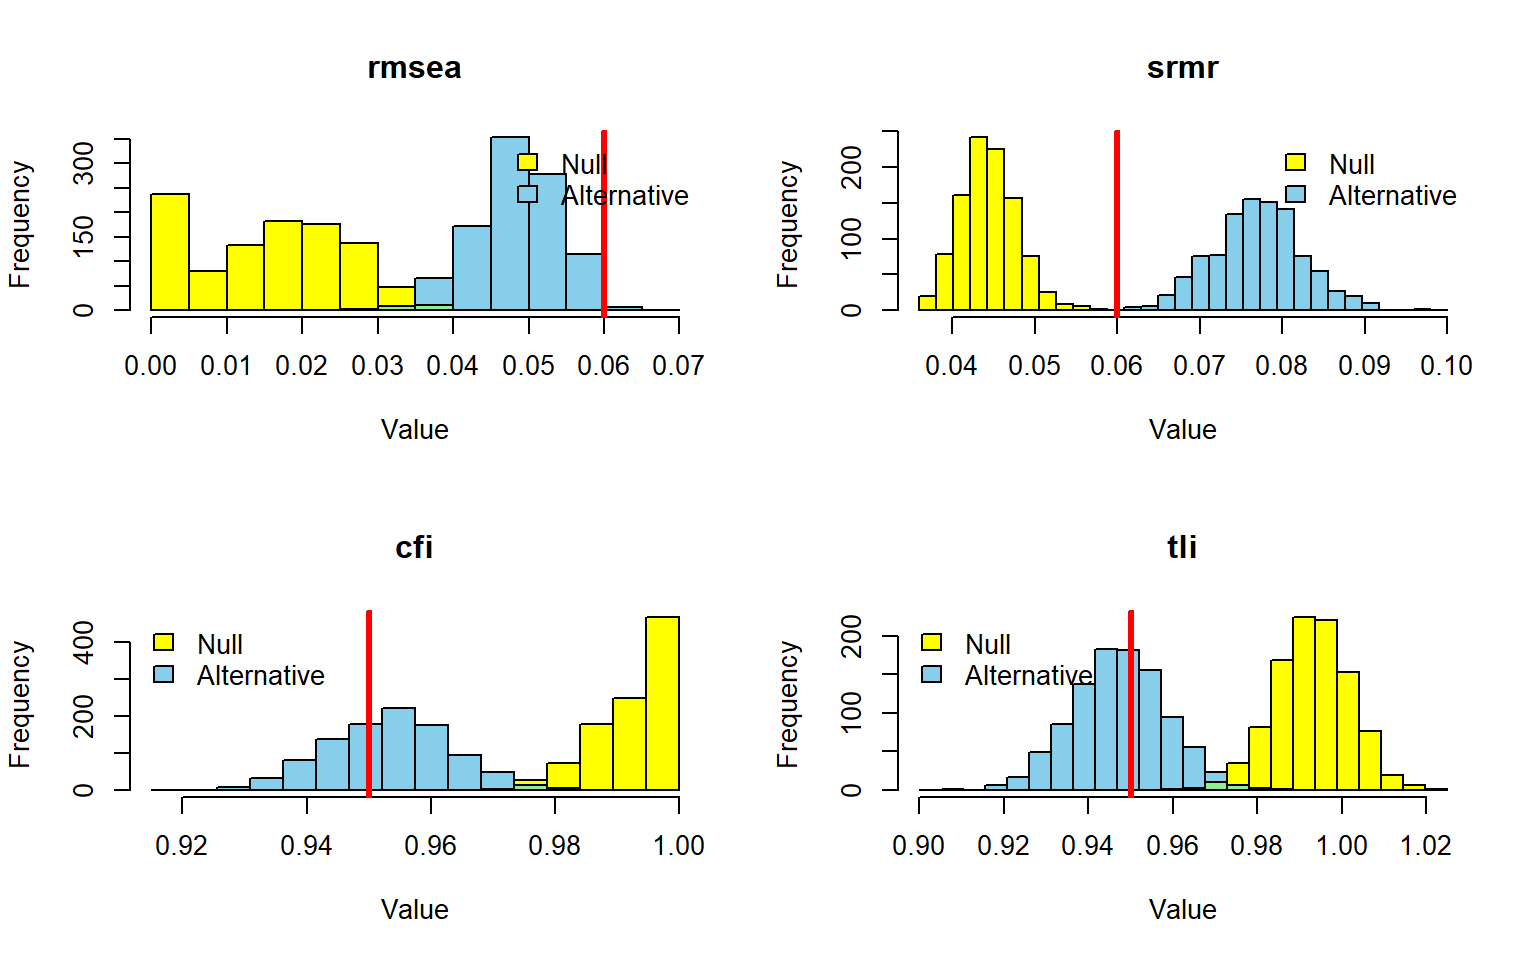

In [ ]:
#| label: fig-curve-fixed-traditional
#| fig-cap: "Power curves using traditional fit index cutoffs with fixed sample size."
#| fig-width: 8
#| fig-height: 5

plotPowerFit(
    h1model_fixed,           # Data simulated under H1 (with cross-loadings)
    popmodel_fixed,          # Data simulated under H0 (null model)
    cutoff = RULE_OF_THUMB,  # Traditional fit-index cutoffs (see helpers.R)
    alpha = ALPHA,           # Significance level (see helpers.R)
    usedFit = FITS           # RMSEA, SRMR, CFI, and TLI fit indices to display (see helpers.R)
)

In [ ]:
#| label: tbl-power-cutoff-traditional-fixed
#| tbl-cap: "Power for traditional fit index cutoffs with fixed sample size."

# Estimate power using traditional fit-index cutoffs.
power_traditional <- getPowerFit(
  h1model_fixed,     # Data simulated under H1 (with cross-loadings)
  RULE_OF_THUMB,     # Traditional fit-index cutoffs (see helpers.R)
  alpha = ALPHA,     # Significance level (see helpers.R)
  usedFit = FITS     # RMSEA, SRMR, CFI, and TLI fit indices to display (see helpers.R)
)

# Convert to a one-row table with column headers.
power_traditional_tbl <- t(as.data.frame(power_traditional))

# Standardize column names for presentation.
colnames(power_traditional_tbl) <- toupper(names(power_traditional))
rownames(power_traditional_tbl) <- "Power"

# Print the table.
knitr::kable(power_traditional_tbl, digits = 3, align = "c")

            CFI     TLI    RMSEA   SRMR
  ------- ------- ------- ------- -------
  Power    0.354   0.587   0.007   0.999
